Inputs to the analyis: `image.tif`, `pca.tif`, `msu_pts.gpkg`
* Read in all inputs.
* Identify smaller AOI tile.
* Extract DINOv3 embedding for the window that contains the MSU tree point.
* Extract PCA vector from pca.tif at the MSU tree point location.
* Create table with x, y, species, token_row, token_col, pca_vec, embed_vec
* Create two pairs of sets: within species, across species
* Compute cosine distance for some pairs
* Create visualization to show results

test site: `kev_2023-07-21`

In [8]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path("../dinov3").resolve()))
sys.path.insert(0, str(Path('../src').resolve()))

import cosine_similarity as cs

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Implement
1. Identify smaller AOI tile
2. Extract features for each tree location
3. Calculate similarity

In [ ]:
cs.aoi_clip(
    image_path="../data/msu_images/kev_2023-07-21_cropped.tif",
    pca_path="../data/pca/kev_2023-07-21_cropped_pca.tif",
    trees_path="../data/msu_field/_clean/kev_fielddata_clean.gpkg",
    img_out_path="../data/tmp/kev_2023-07-21_maxar_aoi.tif",
    pca_out_path="../data/tmp/kev_2023-07-21_pca_aoi.tif",
    buffer_m=30.0,
)

### Interpretation
* distance ≈ 0.0 → almost identical vectors, same species pairs should have lower distances (blue)
* distance ≈ 1.0 → unrelated vectors, different species pairs should have higher distances (yellow)

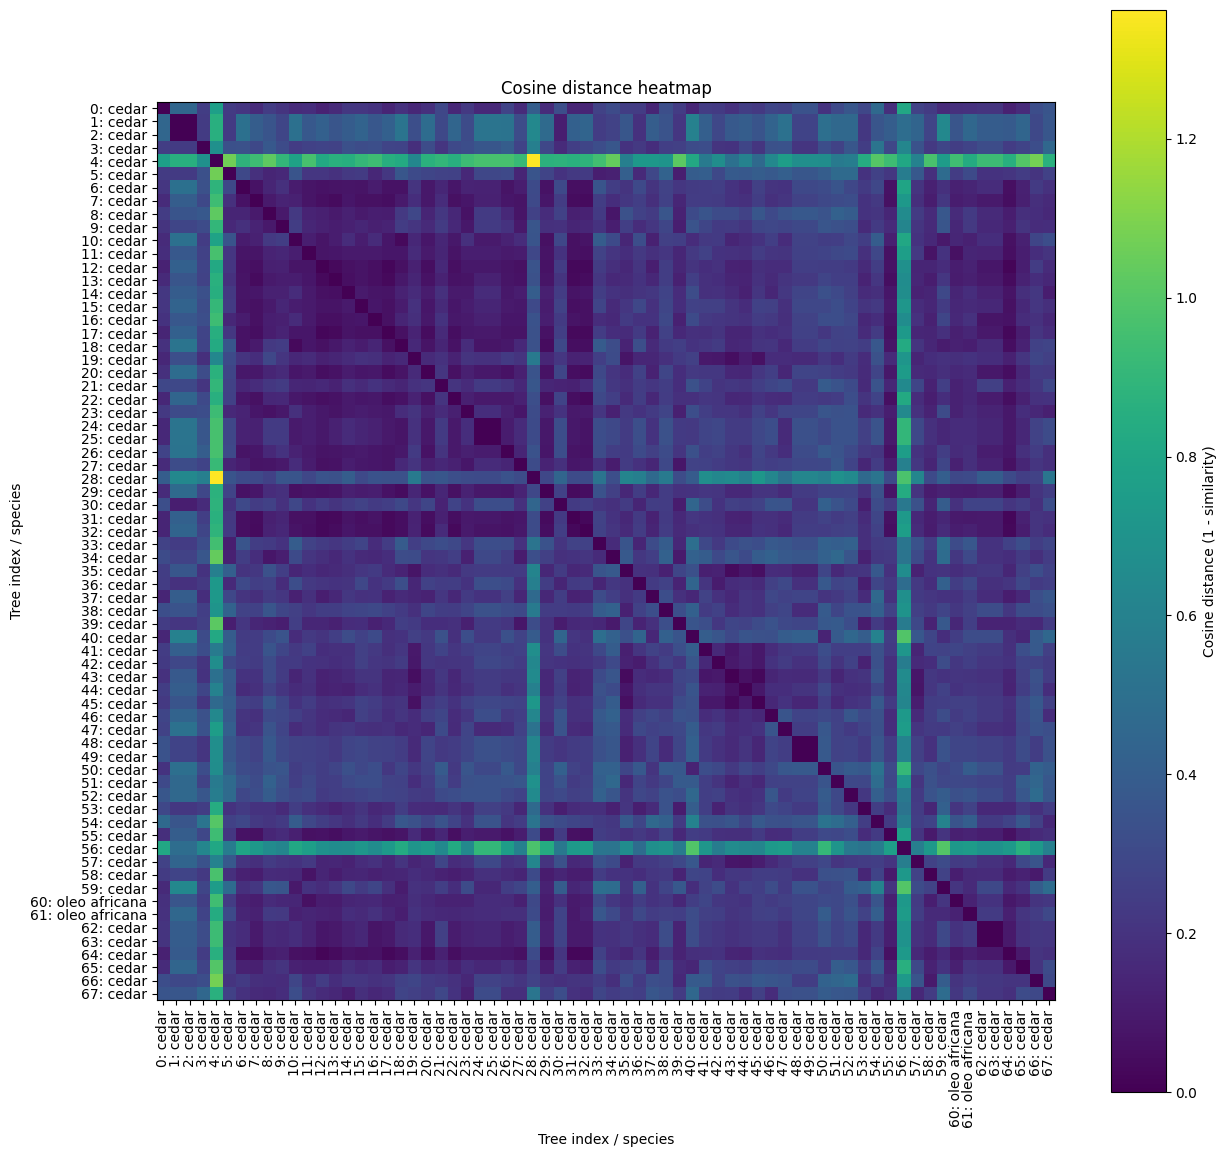

In [16]:
results = cs.per_tree_features("../data/tmp/kev_2023-07-21_maxar_aoi.tif",
                              "../data/tmp/kev_2023-07-21_pca_aoi.tif",
                              "../data/msu_field/_clean/kev_fielddata_clean.gpkg",
                              "../data/tmp/kev_2023-07-21_features.npz")

cs.plot_cosine_distance_heatmap(dist_matrix, species)

sim_matrix, dist_matrix, species, fids = cs.calc_similarity_scores(results)
cs.plot_cosine_distance_heatmap(dist_matrix, species, fids)

Reprojecting trees to src_img CRS...
Dropping 141 tree points outside the image extent.
Index(['sid', 'project_na', 'pid', 'date', 'treeid', 'lat_t', 'long_t',
       'cluster', 'dbh__cm_', 'crown_d_ma', 'crown_d_90', 'height', 'remarks',
       'species_raw', 'species_norm', 'geometry'],
      dtype='object')
Extracting information for 70/211 valid tree points.
Saved to ../data/tmp/ileg_2024-05-13_features.npz
Species count: {'eucalyptus': 5, 'jacaranda mimosifolia': 1, 'grevillea robusta': 20, 'casuarina equisetifolia': 5, 'mangifera indica': 3, 'macadamia integrifolia': 7, 'psidium guajava': 1, 'trichilia emetica': 1, 'albizia coriaria': 10, 'citrus sinensis': 5, 'markhamia lutea': 12}
Embeddings shape: (70, 768)


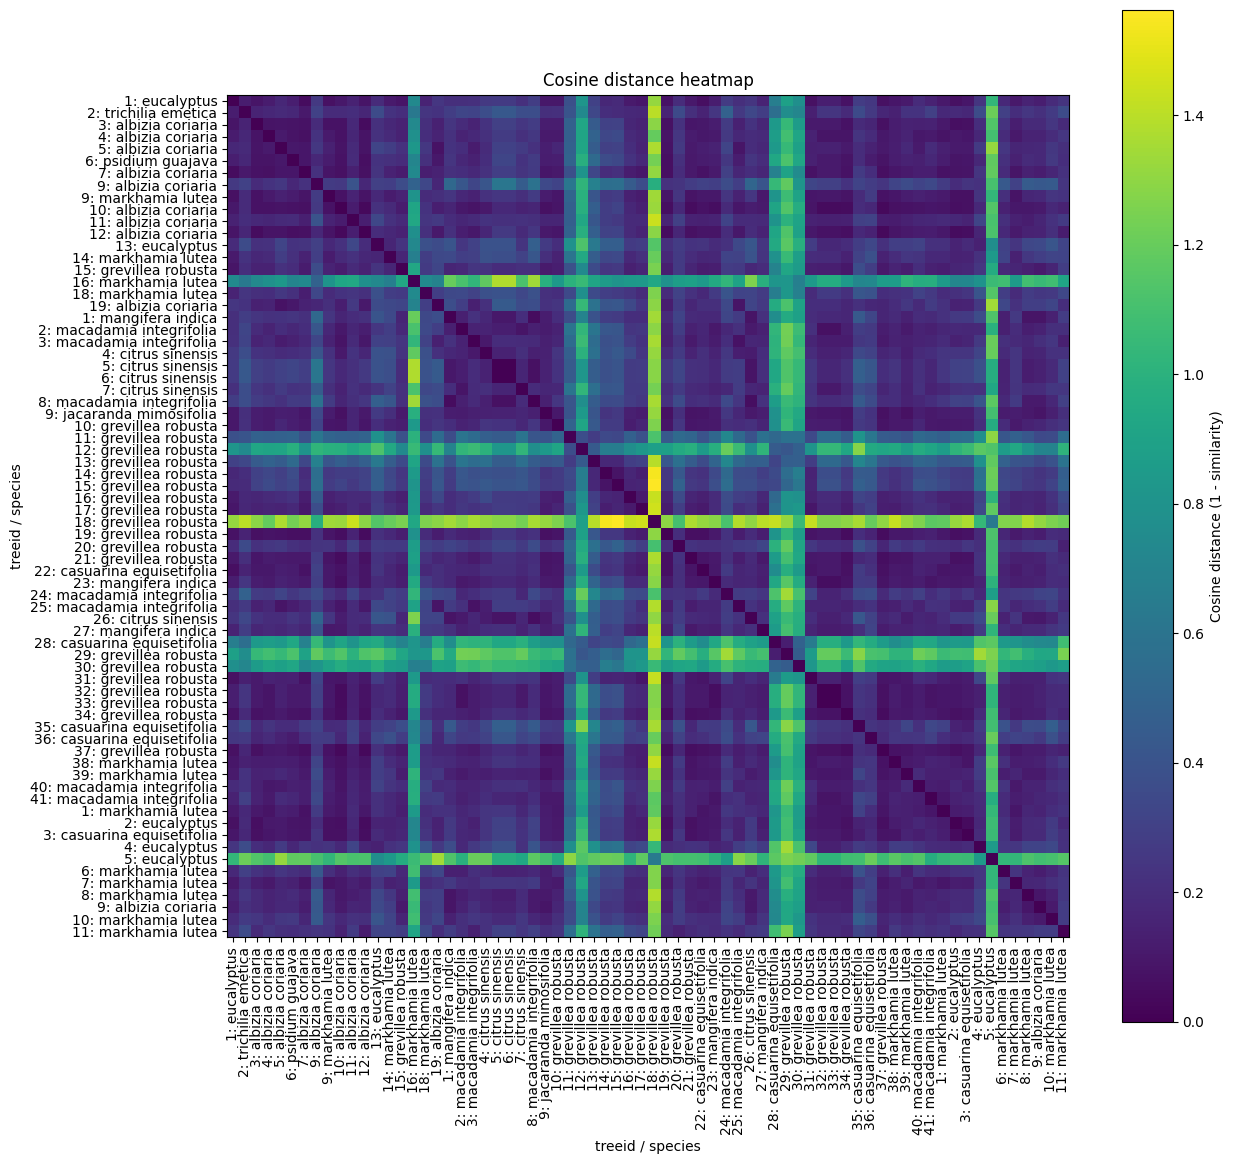

In [22]:
# Perform same process for another image with many different species?
img = 'ileg_2024-05-13'

# cs.aoi_clip(
#     image_path= f"../data/pca/{img}_cropped.tif",
#     pca_path= f"../data/pca/{img}_cropped_pca.tif",
#     trees_path= "../data/msu_field/_clean/ileg_fielddata_clean.gpkg",
#     img_out_path=f"../data/tmp/{img}_maxar_aoi.tif",
#     pca_out_path=f"../data/tmp/{img}_pca_aoi.tif",
#     buffer_m=30.0,
# )


results = cs.per_tree_features(f"../data/tmp/{img}_maxar_aoi.tif",
                              f"../data/tmp/{img}_pca_aoi.tif",
                              "../data/msu_field/_clean/ileg_fielddata_clean.gpkg",
                              f"../data/tmp/{img}_features.npz")

sim_matrix, dist_matrix, species, fids = cs.calc_similarity_scores(results)
cs.plot_cosine_distance_heatmap(dist_matrix, species, fids)